In [1]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from dynamic_routing_analysis import spike_utils, plot_utils
import dynamic_routing_analysis as dra
import os

%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
# load data
# regenerate_table=False
# all_data_loadpath=dra.SINGLE_UNIT_METRICS_PATH / "combined" / "all_data_plus_performance.pkl"
# all_data_loadpath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO single unit metrics\v272_2025-08-15\stim_context_lick_modulation.parquet"
# all_data_loadpath=r"D:\CO single unit metrics\v272_2025-08-15\stim_context_lick_modulation.parquet"
# all_data_loadpath='s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/units_with_activity_metrics_exclude_instruction_trials.parquet'
# all_data_loadpath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO single unit metrics\v272_2025-08-15\stim_context_lick_modulation_exclude_instruction_trials.parquet"
all_data_loadpath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO single unit metrics\v272_2026-06-01\stim_context_lick_modulation.parquet"

# if regenerate_table:
#     savepath = dra.SINGLE_UNIT_METRICS_PATH / "combined"
#     stim_context_loadpath = dra.SINGLE_UNIT_METRICS_PATH
#     lick_loadpath = dra.SINGLE_UNIT_METRICS_PATH / "lick_modulation"
#     performance_loadpath = os.path.join(savepath,"performance_dict.pkl")
#     spike_utils.concat_single_unit_metrics_across_sessions(stim_context_loadpath=stim_context_loadpath,lick_loadpath=lick_loadpath,
#                                                            performance_loadpath=None,savepath=savepath)

# all_data = pd.read_pickle(all_data_loadpath)

all_data = pd.read_parquet(all_data_loadpath)

# #temp hack take first x characters of session id to match with dr_session_list
# all_data['session_id'] = all_data['session_id'].str.slice(0,17)

In [3]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
# session_table_path="/Users/ethan.mcbride/Data/DR/session_table_v0.265.csv"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    )['session_id'].to_list()
    )

templeton_session_list=(
    session_table.filter(
    pl.col('project')=="Templeton",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    )['session_id'].to_list()
)

block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
}

for sel_session in dr_session_list:
    
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)

    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_session_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2')['session_id'].values

In [267]:
sel_project='DynamicRouting'
# sel_project='Templeton'
sel_units=all_data.query('presence_ratio>=0.7 and \
                            isi_violations_ratio<=0.5 and \
                            amplitude_cutoff<=0.1 and \
                            activity_drift<=0.1 and \
                            project.str.contains(@sel_project) and \
                            ~structure.isna() and ~location.isna() and \
                            firing_rate >= 1 and \
                            session_id in @dr_session_list',)
                            # session_id in @templeton_session_list')  
                            

structure_grouping = {
    'SCop': 'SCs',
    'SCsg': 'SCs',
    'SCzo': 'SCs',
    'SCig': 'SCm',
    'SCiw': 'SCm',
    'SCdg': 'SCm',
    'SCdw': 'SCm',
    "ECT1": 'ECT',
    "ECT2/3": 'ECT',    
    "ECT6b": 'ECT',
    "ECT5": 'ECT',
    "ECT6a": 'ECT', 
    "ECT4": 'ECT',
}

exclude_structure_list = [
    'root','lot','ECT2/3','ECT5','ECT6a','ECT6b','CTXsp','MB','OLF','TH','HY','SCsg','SCzo',
    'SCop','SCig','SCiw','SCdg','SCdw','STR','PAL','VL','V3','SEZ','out of brain']

for structure, group in structure_grouping.items():
    sel_units.loc[sel_units['structure'] == structure, 'structure'] = group

sel_units=sel_units.query('structure not in @exclude_structure_list')

adj_pvals=spike_utils.calculate_single_unit_metric_adjusted_pvals(sel_units,sel_project)

In [268]:
sel_units.columns.values
# session_wise_results
# data

array(['index', 'activity_drift', 'amplitude', 'amplitude_cutoff',
       'amplitude_cv_median', 'amplitude_cv_range', 'amplitude_median',
       'ccf_ap', 'ccf_dv', 'ccf_ml', 'channels', 'cluster_id', 'd_prime',
       'decoder_label', 'decoder_probability', 'default_qc',
       'device_name', 'drift_mad', 'drift_ptp', 'drift_std',
       'electrode_group_name', 'exp_decay', 'firing_range', 'firing_rate',
       'half_width', 'is_not_drift', 'isi_violations_count',
       'isi_violations_ratio', 'isolation_distance', 'l_ratio',
       'location', 'nn_hit_rate', 'nn_miss_rate', 'num_negative_peaks',
       'num_positive_peaks', 'num_spikes', 'peak_channel',
       'peak_electrode', 'peak_to_valley', 'peak_trough_ratio',
       'peak_waveform_index', 'presence_ratio', 'recovery_slope',
       'repolarization_slope', 'rp_contamination', 'rp_violations',
       'silhouette', 'sliding_rp_violation', 'snr', 'spread', 'structure',
       'sync_spike_2', 'sync_spike_4', 'sync_spike_8', 'unit_

In [269]:
# sub_sel_units=sel_units.query('(vis1_stimulus_modulation_p_value<0.05 or sound1_stimulus_modulation_p_value<0.05) and (vis1_context_modulation_p_value<0.05 or sound1_context_modulation_p_value<0.05)')
# sub_sel_units=sel_units.query('vis1_stimulus_modulation_p_value<0.05 and vis1_context_modulation_p_value<0.05 and baseline_context_modulation_p_value<0.05 and baseline_context_modulation_sign==1')
# sub_sel_units=sel_units.query('sound1_stimulus_modulation_p_value<0.05 and sound1_context_modulation_p_value<0.05 and baseline_context_modulation_p_value<0.05 and baseline_context_modulation_sign==-1')
# sub_sel_units=sel_units.query('vis1_stimulus_modulation_p_value<0.05 and baseline_context_modulation_p_value<0.05')
# sub_sel_units=sel_units.query('sound1_stimulus_modulation_p_value<0.05')
# sub_sel_units=sel_units.query('sound1_stimulus_modulation_p_value<0.05 or sound1_stimulus_modulation_p_value<0.05')
sub_sel_units=sel_units

Text(0.5, 0.98, 'all structures; n=40877 units')

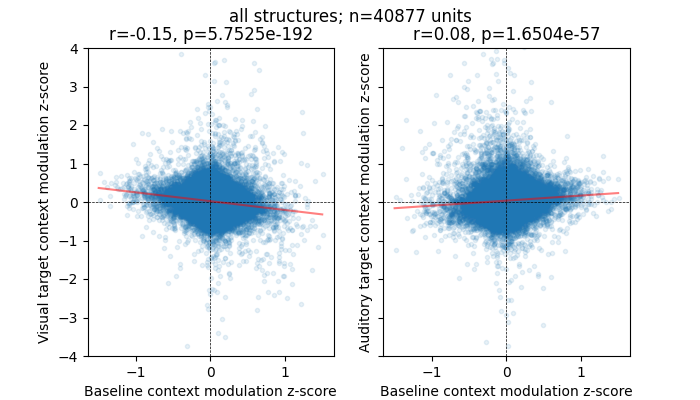

In [270]:
#plot stimulus modulation zscore versus context modulation zscore

#linear regression to fit lines on baseline vs stim context modulation


fig,ax=plt.subplots(1,2,figsize=(7,4),sharex=True,sharey=True)
ax[0].plot(sub_sel_units['baseline_context_modulation_zscore'], sub_sel_units['vis1_evoked_context_modulation_zscore'], '.', alpha=0.1, )
ax[0].set_xlabel('Baseline context modulation z-score')
ax[0].set_ylabel('Visual target context modulation z-score')
ax[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
ax[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
ax[0].set_ylim([-4,4])

array1=sub_sel_units['baseline_context_modulation_zscore'].values
array2=sub_sel_units['vis1_evoked_context_modulation_zscore'].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
x_array=np.array([-1.5,1.5])
ax[0].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax[0].set_title(f'r={r:.2f}, p={p:.4e}')

ax[1].plot(sub_sel_units['baseline_context_modulation_zscore'], sub_sel_units['sound1_evoked_context_modulation_zscore'], '.', alpha=0.1, )
ax[1].set_xlabel('Baseline context modulation z-score')
ax[1].set_ylabel('Auditory target context modulation z-score')
ax[1].axhline(0, color='k', linestyle='--', linewidth=0.5)
ax[1].axvline(0, color='k', linestyle='--', linewidth=0.5)
ax[1].set_ylim([-4,4])

array1=sub_sel_units['baseline_context_modulation_zscore'].values
array2=sub_sel_units['sound1_evoked_context_modulation_zscore'].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
x_array=np.array([-1.5,1.5])
ax[1].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax[1].set_title(f'r={r:.2f}, p={p:.4e}')

fig.suptitle(f'all structures; n={len(sel_units)} units')

Text(0.5, 0.98, 'all structures; n=40877 units')

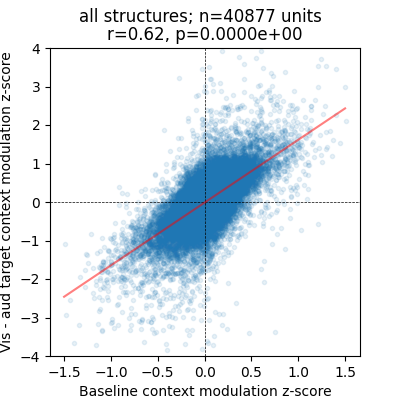

In [271]:
fig,ax=plt.subplots(1,1,figsize=(4,4),sharex=True,sharey=True)
ax.plot(sel_units['baseline_context_modulation_zscore'], sel_units['vis1_context_modulation_zscore']-sel_units['sound1_context_modulation_zscore'], '.', alpha=0.1, )
ax.set_xlabel('Baseline context modulation z-score')
ax.set_ylabel('Vis - aud target context modulation z-score')
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylim([-4,4])

array1=sel_units['baseline_context_modulation_zscore'].values
array2=(sel_units['vis1_context_modulation_zscore']-sel_units['sound1_context_modulation_zscore']).values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
x_array=np.array([-1.5,1.5])
ax.plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax.set_title(f'r={r:.2f}, p={p:.4e}')

fig.suptitle(f'all structures; n={len(sel_units)} units')

Text(0.5, 0.98, 'all structures; n=40877 units')

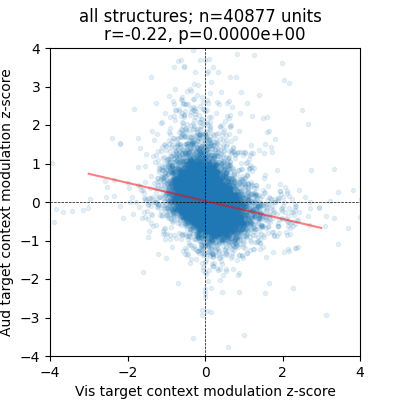

In [272]:
fig,ax=plt.subplots(1,1,figsize=(4,4),sharex=True,sharey=True)
ax.plot(sel_units['vis1_context_modulation_zscore'],sel_units['sound1_context_modulation_zscore'], '.', alpha=0.1, )
ax.set_xlabel('Vis target context modulation z-score')
ax.set_ylabel('Aud target context modulation z-score')
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylim([-4,4])
ax.set_xlim([-4,4])

array1=sel_units['vis1_context_modulation_zscore'].values
array2=sel_units['sound1_context_modulation_zscore'].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
x_array=np.array([-3,3])
ax.plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax.set_title(f'r={r:.2f}, p={p:.4e}')

fig.suptitle(f'all structures; n={len(sel_units)} units')

In [273]:
sel_units.columns.values

array(['index', 'activity_drift', 'amplitude', 'amplitude_cutoff',
       'amplitude_cv_median', 'amplitude_cv_range', 'amplitude_median',
       'ccf_ap', 'ccf_dv', 'ccf_ml', 'channels', 'cluster_id', 'd_prime',
       'decoder_label', 'decoder_probability', 'default_qc',
       'device_name', 'drift_mad', 'drift_ptp', 'drift_std',
       'electrode_group_name', 'exp_decay', 'firing_range', 'firing_rate',
       'half_width', 'is_not_drift', 'isi_violations_count',
       'isi_violations_ratio', 'isolation_distance', 'l_ratio',
       'location', 'nn_hit_rate', 'nn_miss_rate', 'num_negative_peaks',
       'num_positive_peaks', 'num_spikes', 'peak_channel',
       'peak_electrode', 'peak_to_valley', 'peak_trough_ratio',
       'peak_waveform_index', 'presence_ratio', 'recovery_slope',
       'repolarization_slope', 'rp_contamination', 'rp_violations',
       'silhouette', 'sliding_rp_violation', 'snr', 'spread', 'structure',
       'sync_spike_2', 'sync_spike_4', 'sync_spike_8', 'unit_

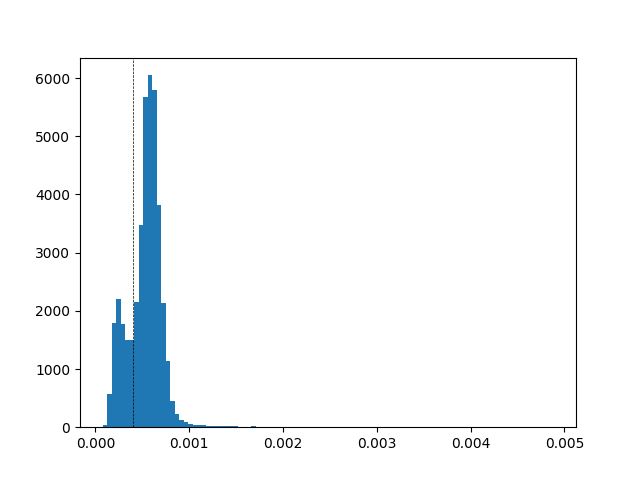

In [274]:
fig,ax=plt.subplots(1,1)
ax.hist(sel_units['peak_to_valley'],bins=100)
ax.axvline(0.0004, color='k', linestyle='--', linewidth=0.5)

In [275]:
# sub_sel_units=sel_units.query('(vis1_stimulus_modulation_p_value<0.05 or sound1_stimulus_modulation_p_value<0.05) and (vis1_context_modulation_p_value<0.05 or sound1_context_modulation_p_value<0.05)')
# sub_sel_units=sel_units.query('vis1_stimulus_modulation_p_value<0.05')
# sub_sel_units=sel_units.query('sound1_stimulus_modulation_p_value<0.05')
# sub_sel_units=sel_units.query('vis1_stimulus_modulation_p_value<0.05 or sound1_stimulus_modulation_p_value<0.05')
# sub_sel_units=sel_units.query('baseline_context_modulation_p_value<0.05')


# context_mod_zscore=sel_units['baseline_context_modulation_zscore'].values
# context_mod_zscore=context_mod_zscore[np.isfinite(context_mod_zscore) & ~np.isnan(context_mod_zscore)]
# context_mod_zscore_5th_percentile=np.percentile(context_mod_zscore, 5)
# context_mod_zscore_95th_percentile=np.percentile(context_mod_zscore, 95)

# sub_sel_units=sel_units.query('(baseline_context_modulation_zscore<@context_mod_zscore_5th_percentile or \
#                               baseline_context_modulation_zscore>@context_mod_zscore_95th_percentile) and \
#                               baseline_context_modulation_p_value<0.01')

# context_mod_zscore=sel_units['vis1_evoked_context_modulation_zscore'].values
# context_mod_zscore=context_mod_zscore[np.isfinite(context_mod_zscore) & ~np.isnan(context_mod_zscore)]
# context_mod_zscore_5th_percentile=np.percentile(context_mod_zscore, 5)
# context_mod_zscore_95th_percentile=np.percentile(context_mod_zscore, 95)

# sub_sel_units=sel_units.query('(baseline_context_modulation_zscore<@context_mod_zscore_5th_percentile or \
#                               baseline_context_modulation_zscore>@context_mod_zscore_95th_percentile) and \
#                               baseline_context_modulation_p_value<0.01')

sub_sel_units=sel_units

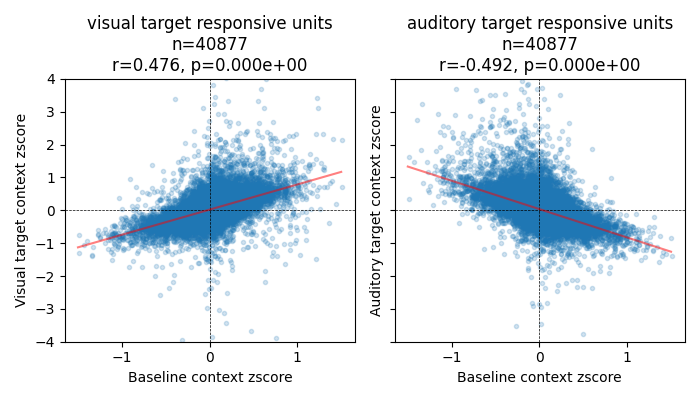

In [276]:
#plot stimulus modulation zscore versus context modulation zscore

sel_structure='all'
# sel_structure=['ORBl','MOs','PL','ILA','SSp','ACAd','MOp','SSs','AId']#,'SCm','MRN','CP']
# sel_structure=['CP']
plot_evoked=False
plot_raw_fr=False
plot_late_modulation=False

if plot_evoked:
    evoked_str='evoked_'
else:
    evoked_str=''

if plot_late_modulation:
    late_str='stimulus_late_'
else:
    late_str=''

if plot_raw_fr:
    metric_str='raw'
else:
    metric_str='zscore'

if sel_structure=='all':
    structure_units=sub_sel_units
else:
    # structure_units=sub_sel_units.query('structure==@sel_structure')
    structure_units=sub_sel_units.query('structure in @sel_structure')

structure_units_vis=structure_units
structure_units_aud=structure_units

# # filter for stim responsive
# structure_units_vis=structure_units.query('vis1_stimulus_modulation_p_value<0.01 and vis1_stimulus_modulation_sign==1')
# structure_units_aud=structure_units.query('sound1_stimulus_modulation_p_value<0.01 and sound1_stimulus_modulation_sign==1')

# structure_units_vis=structure_units.query('vis1_stimulus_modulation_p_value<0.01')
# structure_units_aud=structure_units.query('sound1_stimulus_modulation_p_value<0.01')

# structure_units_vis=structure_units.query(
#     'vis1_stimulus_modulation_p_value<0.05 and vis1_evoked_context_modulation_p_value<0.05 and \
#     baseline_context_modulation_sign==1')
# structure_units_aud=structure_units.query(
#     'sound1_stimulus_modulation_p_value<0.05 and sound1_evoked_context_modulation_p_value<0.05 and \
#     baseline_context_modulation_sign==-1')

#get fit lines and slopes 
#vis1_evoked_stimulus_late_context_modulation

fig,ax=plt.subplots(1,2,figsize=(7,4),sharex=True,sharey=True)
ax[0].plot(structure_units_vis['baseline_context_modulation_'+metric_str], structure_units_vis['vis1_'+evoked_str+late_str+'context_modulation_'+metric_str], '.', alpha=0.2, )
ax[0].set_xlabel('Baseline context '+metric_str)
ax[0].set_ylabel('Visual target '+evoked_str+late_str+'context '+metric_str)
ax[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
ax[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
if plot_raw_fr:
    ax[0].set_ylim([-30,30])
    ax[0].set_xlim([-20,20])
    x_array=np.array([-15,15])
else:
    ax[0].set_ylim([-4,4])
    x_array=np.array([-1.5,1.5])


array1=structure_units_vis['baseline_context_modulation_'+metric_str].values
array2=structure_units_vis['vis1_'+evoked_str+late_str+'context_modulation_'+metric_str].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)

ax[0].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax[0].set_title(f'visual target responsive units\nn={len(structure_units_vis)}\nr={r:.3f}, p={p:.3e}')

ax[1].plot(structure_units_aud['baseline_context_modulation_'+metric_str], structure_units_aud['sound1_'+evoked_str+late_str+'context_modulation_'+metric_str], '.', alpha=0.2, )
ax[1].set_xlabel('Baseline context '+metric_str)
ax[1].set_ylabel('Auditory target '+evoked_str+late_str+'context '+metric_str)
ax[1].axhline(0, color='k', linestyle='--', linewidth=0.5)
ax[1].axvline(0, color='k', linestyle='--', linewidth=0.5)
if plot_raw_fr:
    ax[1].set_ylim([-30,30])
    ax[1].set_xlim([-20,20])
    x_array=np.array([-15,15])
else:
    ax[1].set_ylim([-4,4])
    x_array=np.array([-1.5,1.5])

array1=structure_units_aud['baseline_context_modulation_'+metric_str].values
array2=structure_units_aud['sound1_'+evoked_str+late_str+'context_modulation_'+metric_str].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)

ax[1].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax[1].set_title(f'auditory target responsive units\nn={len(structure_units_aud)}\nr={r:.3f}, p={p:.3e}')


# fig.suptitle(f'{sel_structure} target responsive units; n={len(structure_units_vis)}')
fig.tight_layout()

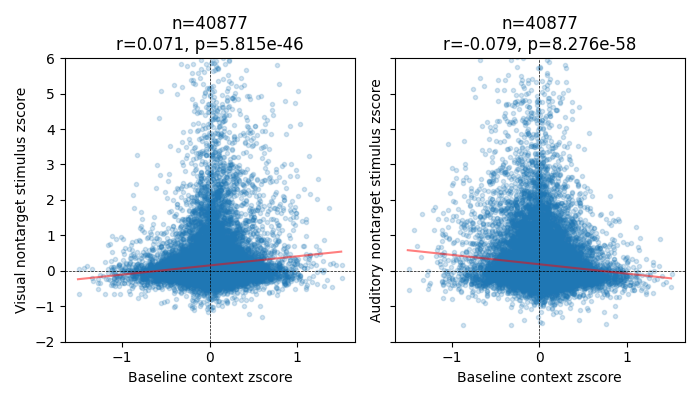

In [277]:
#plot stimulus modulation zscore versus context modulation zscore

sel_structure='all'
# sel_structure=['ORBl','MOs','PL','ILA','SSp','ACAd','MOp','SSs','AId','SCm','MRN','CP']
# sel_structure=['CP']
plot_evoked=False
plot_raw_fr=False
plot_late_modulation=False

if plot_evoked:
    evoked_str='evoked_'
else:
    evoked_str=''

if plot_late_modulation:
    late_str='stimulus_late_'
else:
    late_str=''

if plot_raw_fr:
    metric_str='raw'
else:
    metric_str='zscore'

if sel_structure=='all':
    structure_units=sub_sel_units
else:
    # structure_units=sub_sel_units.query('structure==@sel_structure')
    structure_units=sub_sel_units.query('structure in @sel_structure')

structure_units_vis=structure_units
structure_units_aud=structure_units

# # filter for stim responsive
# structure_units_vis=structure_units.query('vis1_stimulus_modulation_p_value<0.01 and vis1_stimulus_modulation_sign==1')
# structure_units_aud=structure_units.query('sound1_stimulus_modulation_p_value<0.01 and sound1_stimulus_modulation_sign==1')

# structure_units_vis=structure_units.query('vis1_stimulus_modulation_p_value<0.01')
# structure_units_aud=structure_units.query('sound1_stimulus_modulation_p_value<0.01')

# structure_units_vis=structure_units.query(
#     'vis1_stimulus_modulation_p_value<0.05 and vis1_evoked_context_modulation_p_value<0.05 and \
#     baseline_context_modulation_sign==1')
# structure_units_aud=structure_units.query(
#     'sound1_stimulus_modulation_p_value<0.05 and sound1_evoked_context_modulation_p_value<0.05 and \
#     baseline_context_modulation_sign==-1')

#get fit lines and slopes 
#vis1_evoked_stimulus_late_context_modulation

fig,ax=plt.subplots(1,2,figsize=(7,4),sharex=True,sharey=True)
ax[0].plot(structure_units_vis['baseline_context_modulation_'+metric_str], structure_units_vis['vis2_'+evoked_str+late_str+'stimulus_modulation_'+metric_str], '.', alpha=0.2, )
ax[0].set_xlabel('Baseline context '+metric_str)
ax[0].set_ylabel('Visual nontarget '+evoked_str+late_str+'stimulus '+metric_str)
ax[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
ax[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
if plot_raw_fr:
    ax[0].set_ylim([-30,30])
    ax[0].set_xlim([-20,20])
    x_array=np.array([-15,15])
else:
    ax[0].set_ylim([-2,6])
    x_array=np.array([-1.5,1.5])


array1=structure_units_vis['baseline_context_modulation_'+metric_str].values
array2=structure_units_vis['vis2_'+evoked_str+late_str+'stimulus_modulation_'+metric_str].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)

ax[0].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax[0].set_title(f'n={len(structure_units_vis)}\nr={r:.3f}, p={p:.3e}')

ax[1].plot(structure_units_aud['baseline_context_modulation_'+metric_str], structure_units_aud['sound2_'+evoked_str+late_str+'stimulus_modulation_'+metric_str], '.', alpha=0.2, )
ax[1].set_xlabel('Baseline context '+metric_str)
ax[1].set_ylabel('Auditory nontarget '+evoked_str+late_str+'stimulus '+metric_str)
ax[1].axhline(0, color='k', linestyle='--', linewidth=0.5)
ax[1].axvline(0, color='k', linestyle='--', linewidth=0.5)
if plot_raw_fr:
    ax[1].set_ylim([-30,30])
    ax[1].set_xlim([-20,20])
    x_array=np.array([-15,15])
else:
    ax[1].set_ylim([-2,6])
    x_array=np.array([-1.5,1.5])

array1=structure_units_aud['baseline_context_modulation_'+metric_str].values
array2=structure_units_aud['sound2_'+evoked_str+late_str+'stimulus_modulation_'+metric_str].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)

ax[1].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax[1].set_title(f'n={len(structure_units_aud)}\nr={r:.3f}, p={p:.3e}')


# fig.suptitle(f'{sel_structure} target responsive units; n={len(structure_units_vis)}')
fig.tight_layout()

C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_19640\2182588386.py:70: RuntimeWarning: invalid value encountered in subtract
  array2=structure_units_vis['vis1_'+evoked_str+late_str+'stimulus_modulation_'+metric_str].values-structure_units_vis['sound1_'+evoked_str+late_str+'stimulus_modulation_'+metric_str].values


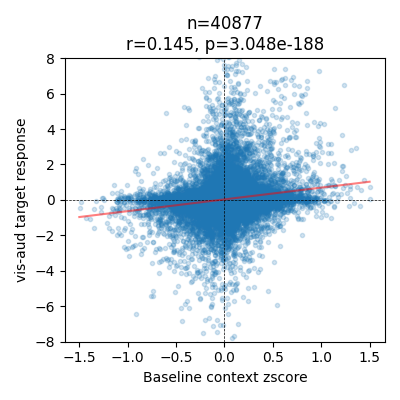

In [278]:
# 'target_discrim_roc_auc'

#plot stimulus modulation zscore versus context modulation zscore

sel_structure='all'
# sel_structure=['ORBl','MOs','PL','ILA','SSp','ACAd','MOp','SSs','AId']#,'SCm','MRN','CP']
# sel_structure=['CP']

plot_evoked=False
plot_raw_fr=False
plot_late_modulation=False

if plot_evoked:
    evoked_str='evoked_'
else:
    evoked_str=''

if plot_late_modulation:
    late_str='stimulus_late_'
else:
    late_str=''

if plot_raw_fr:
    metric_str='raw'
else:
    metric_str='zscore'

if sel_structure=='all':
    structure_units=sub_sel_units
else:
    # structure_units=sub_sel_units.query('structure==@sel_structure')
    structure_units=sub_sel_units.query('structure in @sel_structure')

structure_units_vis=structure_units
structure_units_aud=structure_units

# # filter for stim responsive
# structure_units_vis=structure_units.query('vis1_stimulus_modulation_p_value<0.01 and vis1_stimulus_modulation_sign==1')
# structure_units_aud=structure_units.query('sound1_stimulus_modulation_p_value<0.01 and sound1_stimulus_modulation_sign==1')

# structure_units_vis=structure_units.query('vis1_stimulus_modulation_p_value<0.01')
# structure_units_aud=structure_units.query('sound1_stimulus_modulation_p_value<0.01')

# structure_units_vis=structure_units.query(
#     'vis1_stimulus_modulation_p_value<0.05 and vis1_evoked_context_modulation_p_value<0.05 and \
#     baseline_context_modulation_sign==1')
# structure_units_aud=structure_units.query(
#     'sound1_stimulus_modulation_p_value<0.05 and sound1_evoked_context_modulation_p_value<0.05 and \
#     baseline_context_modulation_sign==-1')

#get fit lines and slopes 
#vis1_evoked_stimulus_late_context_modulation

fig,ax=plt.subplots(1,1,figsize=(4,4),sharex=True,sharey=True)
ax.plot(structure_units_vis['baseline_context_modulation_'+metric_str], #
        structure_units_vis['vis1_'+evoked_str+late_str+'stimulus_modulation_'+metric_str]-
        structure_units_vis['sound1_'+evoked_str+late_str+'stimulus_modulation_'+metric_str], '.', alpha=0.2, )
ax.set_xlabel('Baseline context '+metric_str)
ax.set_ylabel('vis-aud '+evoked_str+late_str+'target response')
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
if plot_raw_fr:
    ax.set_ylim([-30,30])
    x_array=np.array([-15,15])
else:
    ax.set_ylim([-8,8])
    x_array=np.array([-1.5,1.5])

array1=structure_units_vis['baseline_context_modulation_'+metric_str].values
array2=structure_units_vis['vis1_'+evoked_str+late_str+'stimulus_modulation_'+metric_str].values-structure_units_vis['sound1_'+evoked_str+late_str+'stimulus_modulation_'+metric_str].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)

ax.plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax.set_title(f'n={len(structure_units_vis)}\nr={r:.3f}, p={p:.3e}')



# fig.suptitle(f'{sel_structure} target responsive units; n={len(structure_units_vis)}')
fig.tight_layout()

C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_19640\1264314167.py:62: RuntimeWarning: invalid value encountered in subtract
  structure_units['vis1_'+evoked_str+late_str+'stimulus_modulation_same_context_'+metric_str].values-
C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_19640\1264314167.py:66: RuntimeWarning: invalid value encountered in subtract
  structure_units['vis1_'+evoked_str+late_str+'stimulus_modulation_other_context_'+metric_str].values-


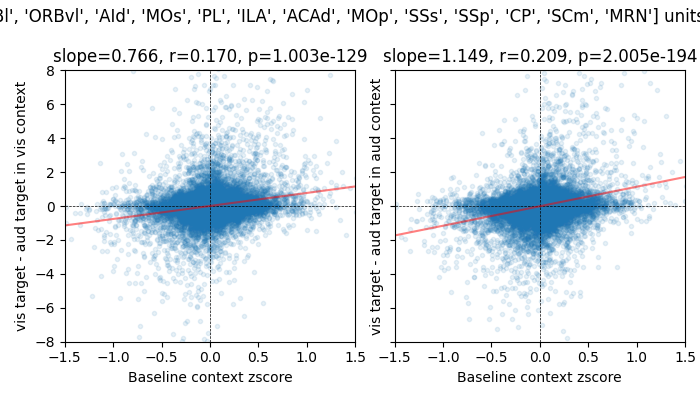

In [279]:
#plot context-specific stimulus modulation metrics versus context modulation 

# 'vis1_stimulus_modulation_same_context_raw' vs 'sound1_stimulus_modulation_other_context_raw'

# sel_structure='all'
# sel_structure=['ORBl','MOs','PL','ACAd','AId']#,'SCm','MRN','CP']
sel_structure=['FRP','ORBl','ORBvl','AId','MOs','PL','ILA','ACAd','MOp','SSs','SSp','CP','SCm','MRN']
# sel_structure=['CA1','DG','VISp','VISl','VISli','VISpm','VISpor','LGd','LGv','LP','LD','RSPd',
#                'RSPv','MGv','MGd','MGm','LSr','SUB','LSc','AUDpo','AUDd','AUDp']

plot_evoked=True
plot_raw_fr=False
plot_late_modulation=False


if plot_evoked:
    evoked_str='evoked_'
else:
    evoked_str=''

if plot_late_modulation:
    late_str='stimulus_late_'
else:
    late_str=''

if plot_raw_fr:
    metric_str='raw'
else:
    metric_str='zscore'

if sel_structure=='all':
    structure_units=sub_sel_units
else:
    # structure_units=sub_sel_units.query('structure==@sel_structure')
    structure_units=sub_sel_units.query('structure in @sel_structure')

# structure_units=structure_units.query('((vis1_stimulus_modulation_p_value<0.01 and vis1_stimulus_modulation_sign==1) or \
#                                        (sound1_stimulus_modulation_p_value<0.01 and sound1_stimulus_modulation_sign==1)) and \
#                                        baseline_context_modulation_sign==-1 and baseline_context_modulation_p_value<0.01')

# structure_units=structure_units.query('peak_to_valley<0.0004')

# structure_units=structure_units.query('baseline_context_modulation_sign==1 and baseline_context_modulation_p_value<0.01 and \
#                                        (vis1_stimulus_modulation_p_value<0.01 and vis1_stimulus_modulation_sign==1)')
# structure_units=structure_units.query('baseline_context_modulation_sign==-1 and baseline_context_modulation_p_value<0.01 and \
#                                        (sound1_stimulus_modulation_p_value<0.01 and sound1_stimulus_modulation_sign==1)')

# structure_units=structure_units.query('baseline_context_modulation_sign==1 and (sound1_stimulus_modulation_p_value<0.01 or vis1_stimulus_modulation_p_value<0.01)')

# structure_units=structure_units.query('(sound1_stimulus_modulation_p_value<0.01 or vis1_stimulus_modulation_p_value<0.01)')

#get fit lines and slopes 
#vis1_evoked_stimulus_late_context_modulation

# vis_target_vis_context_selectivity=(
#     structure_units['vis1_'+evoked_str+late_str+'stimulus_modulation_same_context_'+metric_str].values-
#     structure_units['sound1_'+evoked_str+late_str+'stimulus_modulation_same_context_'+metric_str].values
# )

#target selectivity in vis context
vis_target_vis_context_selectivity=(
    structure_units['vis1_'+evoked_str+late_str+'stimulus_modulation_same_context_'+metric_str].values-
    structure_units['sound1_'+evoked_str+late_str+'stimulus_modulation_other_context_'+metric_str].values
)
vis_target_aud_context_selectivity=(
    structure_units['vis1_'+evoked_str+late_str+'stimulus_modulation_other_context_'+metric_str].values-
    structure_units['sound1_'+evoked_str+late_str+'stimulus_modulation_same_context_'+metric_str].values
)

# vis_target_vis_context_selectivity=(
#     structure_units['vis1_'+evoked_str+late_str+'stimulus_modulation_same_context_'+metric_str].values-
#     structure_units['vis1_'+evoked_str+late_str+'stimulus_modulation_other_context_'+metric_str].values
# )
# vis_target_aud_context_selectivity=(
#     structure_units['sound1_'+evoked_str+late_str+'stimulus_modulation_other_context_'+metric_str].values-
#     structure_units['sound1_'+evoked_str+late_str+'stimulus_modulation_same_context_'+metric_str].values
# )

fig,ax=plt.subplots(1,2,figsize=(7,4),sharex=True,sharey=True)
ax[0].plot(structure_units['baseline_context_modulation_'+metric_str], #
        vis_target_vis_context_selectivity, '.', alpha=0.1, )
ax[0].set_xlabel('Baseline context '+metric_str)
ax[0].set_ylabel('vis target - aud target in vis context')
ax[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
ax[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
if plot_raw_fr:
    ax[0].set_ylim([-40,40])
    ax[0].set_xlim([-20,20])
    x_array=np.array([-15,15])
else:
    ax[0].set_ylim([-8,8])
    ax[0].set_xlim([-1.5,1.5])
    x_array=np.array([-1.5,1.5])

array1=structure_units['baseline_context_modulation_'+metric_str].values
array2=vis_target_vis_context_selectivity
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)

ax[0].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax[0].set_title(f'slope={slope:.3f}, r={r:.3f}, p={p:.3e}')

ax[1].plot(structure_units['baseline_context_modulation_'+metric_str], #
        vis_target_aud_context_selectivity, '.', alpha=0.1, )
ax[1].set_xlabel('Baseline context '+metric_str)
ax[1].set_ylabel('vis target - aud target in aud context')
ax[1].axhline(0, color='k', linestyle='--', linewidth=0.5)
ax[1].axvline(0, color='k', linestyle='--', linewidth=0.5)
if plot_raw_fr:
    ax[1].set_ylim([-40,40])
    ax[1].set_xlim([-20,20])
    x_array=np.array([-15,15])
else:
    ax[1].set_ylim([-8,8])
    ax[1].set_xlim([-1.5,1.5])
    ax[1].set_xlim([-1.5,1.5])
    x_array=np.array([-1.5,1.5])

array1=structure_units['baseline_context_modulation_'+metric_str].values
array2=vis_target_aud_context_selectivity
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
ax[1].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax[1].set_title(f'slope={slope:.3f}, r={r:.3f}, p={p:.3e}')

fig.suptitle(f'{sel_structure} units; n={len(structure_units)}')
fig.tight_layout()

        

In [280]:
array2=vis_target_vis_context_selectivity
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
np.nanmedian(vis_target_vis_context_selectivity[valid_indices])


# array2=vis_target_aud_context_selectivity
# valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
# np.nanmedian(vis_target_aud_context_selectivity[valid_indices])

0.006185917516367212

C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_19640\4167645313.py:1: RuntimeWarning: invalid value encountered in subtract
  vis_target_vis_context_selectivity-vis_target_aud_context_selectivity


array([-0.76480034, -0.0925588 ,         nan, ..., -0.41791376,
        1.41574059,  0.02402938])

C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_19640\956678808.py:14: RuntimeWarning: invalid value encountered in subtract
  diff_values=vis_target_vis_context_selectivity-vis_target_aud_context_selectivity
C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_19640\956678808.py:36: RuntimeWarning: Mean of empty slice
  vis_context_mean_values.append(np.nanmean(vis_context_values[vis_bin_indices]))
C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_19640\956678808.py:37: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  vis_context_sem_values.append(stats.sem(vis_context_values[vis_bin_indices]))
C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_19640\956678808.py:39: RuntimeWarning: Mean of empty slice
  aud_context_mean_values.append(np.nanmean(aud_context_values[aud_bin_indices]))
C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_19640\956678808.py:40: SmallSampleWarning: One or 

Text(0.5, 1.0, "['FRP', 'ORBl', 'ORBvl', 'AId', 'MOs', 'PL', 'ILA', 'ACAd', 'MOp', 'SSs', 'SSp', 'CP', 'SCm', 'MRN'] units; n=20687")

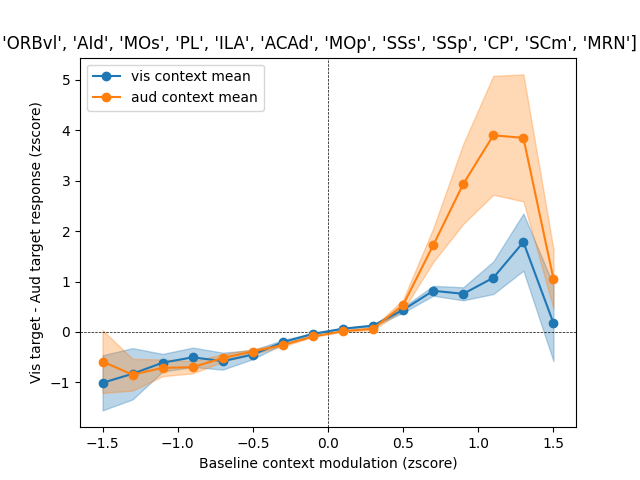

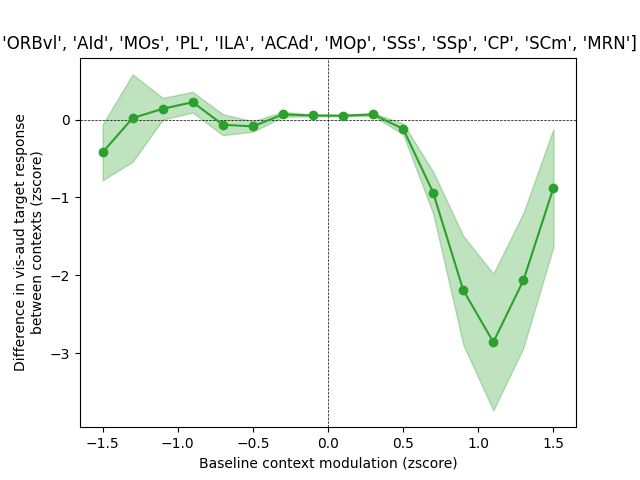

In [286]:
plot_median=False

baseline_values=structure_units['baseline_context_modulation_'+metric_str].values
vis_context_values=vis_target_vis_context_selectivity
valid_indices = np.isfinite(vis_context_values) & ~np.isnan(vis_context_values)
vis_context_values=vis_context_values[valid_indices]
vis_baseline_values=baseline_values[valid_indices]

aud_context_values=vis_target_aud_context_selectivity
valid_indices = np.isfinite(aud_context_values) & ~np.isnan(aud_context_values)
aud_context_values=aud_context_values[valid_indices]
aud_baseline_values=baseline_values[valid_indices]

diff_values=vis_target_vis_context_selectivity-vis_target_aud_context_selectivity
valid_indices = np.isfinite(diff_values) & ~np.isnan(diff_values)
diff_values=diff_values[valid_indices]
diff_baseline_values=baseline_values[valid_indices]

#get mean and median at different baseline context modulation zscore bins
bins=np.arange(-2,2.05,0.2)
bin_centers = (bins[:-1] + bins[1:]) / 2
vis_context_mean_values = []
vis_context_sem_values = []
vis_context_median_values = []
aud_context_mean_values = []
aud_context_sem_values = []
aud_context_median_values = []
diff_mean_values = []
diff_sem_values = []
diff_median_values = []

for i in range(len(bins)-1):
    vis_bin_indices = (vis_baseline_values >= bins[i]) & (vis_baseline_values < bins[i+1])
    aud_bin_indices = (aud_baseline_values >= bins[i]) & (aud_baseline_values < bins[i+1])
    diff_bin_indices = (diff_baseline_values >= bins[i]) & (diff_baseline_values < bins[i+1])
    vis_context_mean_values.append(np.nanmean(vis_context_values[vis_bin_indices]))
    vis_context_sem_values.append(stats.sem(vis_context_values[vis_bin_indices]))
    vis_context_median_values.append(np.nanmedian(vis_context_values[vis_bin_indices]))
    aud_context_mean_values.append(np.nanmean(aud_context_values[aud_bin_indices]))
    aud_context_sem_values.append(stats.sem(aud_context_values[aud_bin_indices]))
    aud_context_median_values.append(np.nanmedian(aud_context_values[aud_bin_indices]))

    diff_mean_values.append(np.nanmean(diff_values[diff_bin_indices]))
    diff_sem_values.append(stats.sem(diff_values[diff_bin_indices]))
    diff_median_values.append(np.nanmedian(diff_values[diff_bin_indices]))

fig,ax=plt.subplots(1,1)
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5)

if plot_median:
    ax.plot(bin_centers, vis_context_median_values, label='vis context median', marker='', color='tab:blue', linestyle='--')
    ax.plot(bin_centers, aud_context_median_values, label='aud context median', marker='', color='tab:orange', linestyle='--')
else:
    ax.plot(bin_centers, vis_context_mean_values, label='vis context mean', marker='o', color='tab:blue')
    ax.fill_between(
        bin_centers, np.array(vis_context_mean_values)-np.array(vis_context_sem_values), 
        np.array(vis_context_mean_values)+np.array(vis_context_sem_values), color='tab:blue', alpha=0.3)
    ax.plot(bin_centers, aud_context_mean_values, label='aud context mean', marker='o', color='tab:orange')
    ax.fill_between(
        bin_centers, np.array(aud_context_mean_values)-np.array(aud_context_sem_values), 
        np.array(aud_context_mean_values)+np.array(aud_context_sem_values), color='tab:orange', alpha=0.3)

ax.set_xlabel('Baseline context modulation ('+metric_str+')')
ax.set_ylabel('Vis target - Aud target response ('+metric_str+')')
ax.set_title(f'{sel_structure} units; n={len(structure_units)}')
ax.legend()

fig,ax=plt.subplots(1,1)
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
if plot_median:
    ax.plot(bin_centers, diff_median_values, label='vis context median - aud context median', marker='', color='tab:green', linestyle='--')
else:
    ax.plot(bin_centers, diff_mean_values, label='vis context mean - aud context mean', marker='o', color='tab:green')
    ax.fill_between(
        bin_centers, np.array(diff_mean_values)-np.array(diff_sem_values), 
        np.array(diff_mean_values)+np.array(diff_sem_values), color='tab:green', alpha=0.3)

ax.set_xlabel('Baseline context modulation ('+metric_str+')')
ax.set_ylabel('Difference in vis-aud target response\nbetween contexts ('+metric_str+')')
ax.set_title(f'{sel_structure} units; n={len(structure_units)}')

In [163]:
# #plot context-specific stimulus modulation metrics versus context modulation 

# # 'vis1_stimulus_modulation_same_context_raw' vs 'sound1_stimulus_modulation_other_context_raw'

# sel_structure='all'
# # sel_structure=['ORBl','MOs','PL','ILA','SSp','ACAd','MOp','SSs','AId']#,'SCm','MRN','CP']
# # sel_structure=['CP']

# plot_evoked=True
# plot_raw_fr=False
# plot_late_modulation=False

# if plot_evoked:
#     evoked_str='evoked_'
# else:
#     evoked_str=''

# if plot_late_modulation:
#     late_str='stimulus_late_'
# else:
#     late_str=''

# if plot_raw_fr:
#     metric_str='raw'
# else:
#     metric_str='zscore'

# if sel_structure=='all':
#     structure_units=sub_sel_units
# else:
#     # structure_units=sub_sel_units.query('structure==@sel_structure')
#     structure_units=sub_sel_units.query('structure in @sel_structure')

# # structure_units=structure_units.query('peak_to_valley<0.0004')

# # structure_units=structure_units.query('baseline_context_modulation_sign==1 and baseline_context_modulation_p_value<0.01 and \
# #                                        (vis1_stimulus_modulation_p_value<0.01 and vis1_stimulus_modulation_sign==1)')
# structure_units=structure_units.query('baseline_context_modulation_sign==-1 and baseline_context_modulation_p_value<0.05 and \
#                                        (sound1_stimulus_modulation_p_value<0.05 and sound1_stimulus_modulation_sign==1)')

# #get fit lines and slopes 
# #vis1_evoked_stimulus_late_context_modulation

# #target selectivity in vis context
# vis_target_vis_context_selectivity=(
#     structure_units['vis1_'+evoked_str+late_str+'stimulus_modulation_same_context_'+metric_str].values-
#     structure_units['sound1_'+evoked_str+late_str+'stimulus_modulation_other_context_'+metric_str].values
# )
# vis_target_aud_context_selectivity=(
#     structure_units['vis1_'+evoked_str+late_str+'stimulus_modulation_other_context_'+metric_str].values-
#     structure_units['sound1_'+evoked_str+late_str+'stimulus_modulation_same_context_'+metric_str].values
# )


# fig,ax=plt.subplots(1,2,figsize=(7,4),sharex=True,sharey=True)
# ax[0].plot(structure_units['baseline_context_modulation_'+metric_str], #
#         vis_target_vis_context_selectivity, '.', alpha=0.1, )
# ax[0].set_xlabel('Baseline context '+metric_str)
# ax[0].set_ylabel('vis target - aud target in vis context')
# ax[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
# ax[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
# if plot_raw_fr:
#     ax[0].set_ylim([-40,40])
#     ax[0].set_xlim([-20,20])
#     x_array=np.array([-15,15])
# else:
#     ax[0].set_ylim([-8,8])
#     ax[0].set_xlim([-1.5,1.5])
#     x_array=np.array([-1.5,1.5])

# array1=structure_units['baseline_context_modulation_'+metric_str].values
# array2=vis_target_vis_context_selectivity
# valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
# slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)

# ax[0].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
# r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
# ax[0].set_title(f'r={r:.3f}, p={p:.3e}')

# ax[1].plot(structure_units['baseline_context_modulation_'+metric_str], #
#         vis_target_aud_context_selectivity, '.', alpha=0.1, )
# ax[1].set_xlabel('Baseline context '+metric_str)
# ax[1].set_ylabel('vis target - aud target in aud context')
# ax[1].axhline(0, color='k', linestyle='--', linewidth=0.5)
# ax[1].axvline(0, color='k', linestyle='--', linewidth=0.5)
# if plot_raw_fr:
#     ax[1].set_ylim([-40,40])
#     ax[1].set_xlim([-20,20])
#     x_array=np.array([-15,15])
# else:
#     ax[1].set_ylim([-8,8])
#     ax[1].set_xlim([-1.5,1.5])
#     ax[1].set_xlim([-1.5,1.5])
#     x_array=np.array([-1.5,1.5])

# array1=structure_units['baseline_context_modulation_'+metric_str].values
# array2=vis_target_aud_context_selectivity
# valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
# slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
# ax[1].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
# r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
# ax[1].set_title(f'r={r:.3f}, p={p:.3e}')

# fig.suptitle(f'{sel_structure} units; n={len(structure_units)}')
# fig.tight_layout()

        

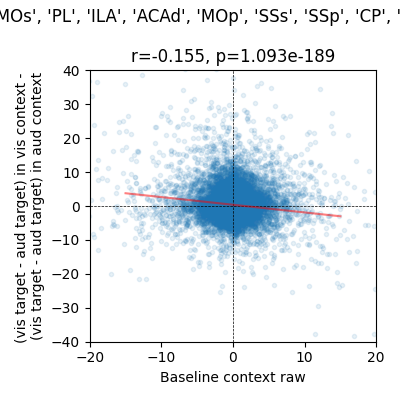

In [248]:
fig,ax=plt.subplots(1,1,figsize=(4,4),sharex=True,sharey=True)
ax.plot(structure_units['baseline_context_modulation_'+metric_str],
        vis_target_vis_context_selectivity-vis_target_aud_context_selectivity, '.', alpha=0.1)
ax.set_xlabel('Baseline context '+metric_str)
ax.set_ylabel('(vis target - aud target) in vis context - \n(vis target - aud target) in aud context')
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
if plot_raw_fr:
    ax.set_ylim([-40,40])
    ax.set_xlim([-20,20])
    x_array=np.array([-15,15])
else:
    ax.set_ylim([-8,8])
    ax.set_xlim([-1.5,1.5])
    x_array=np.array([-1.5,1.5])
array1=structure_units['baseline_context_modulation_'+metric_str].values
array2=vis_target_vis_context_selectivity-vis_target_aud_context_selectivity

valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
ax.plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax.set_title(f'r={r:.3f}, p={p:.3e}')

fig.suptitle(f'{sel_structure} units; n={len(structure_units)}')
fig.tight_layout()

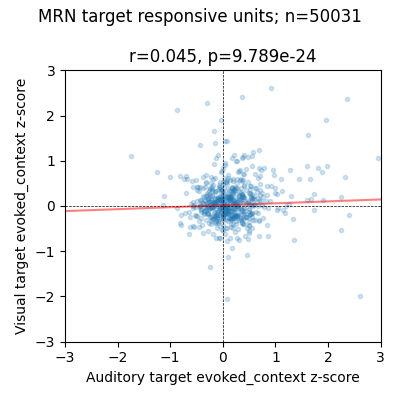

In [18]:
#plot stimulus modulation zscore versus context modulation zscore

sel_structure='MRN'
plot_evoked=True
if plot_evoked:
    evoked_str='evoked_'
else:
    evoked_str=''

if sel_structure=='all':
    structure_units=sel_units
else:
    structure_units=sel_units.query('structure==@sel_structure')

#filter for stim responsive
# structure_units_vis=structure_units.query('vis1_stimulus_modulation_p_value<0.05')
# structure_units_aud=structure_units.query('sound1_stimulus_modulation_p_value<0.05')

# structure_units=structure_units.query('vis1_stimulus_modulation_p_value<0.05 or sound1_stimulus_modulation_p_value<0.05')

#get fit lines and slopes 

fig,ax=plt.subplots(1,1,figsize=(4,4),sharex=True,sharey=True)
ax.plot(structure_units['sound1_'+evoked_str+'context_modulation_zscore'], structure_units['vis1_'+evoked_str+'context_modulation_zscore'], '.', alpha=0.2, )
ax.set_xlabel('Auditory target '+evoked_str+'context z-score')
ax.set_ylabel('Visual target '+evoked_str+'context z-score')
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylim([-3,3])
ax.set_xlim([-3,3])

array1=structure_units_aud['sound1_'+evoked_str+'context_modulation_zscore'].values
array2=structure_units_vis['vis1_'+evoked_str+'context_modulation_zscore'].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
x_array=np.array([-4,4])
ax.plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax.set_title(f'r={r:.3f}, p={p:.3e}')
# ax[0].set_title(f'visual target responsive units\n(n={len(structure_units_vis)}) r={r:.3f}, p={p:.3e}')

# ax[1].plot(structure_units_aud['baseline_context_modulation_zscore'], structure_units_aud['sound1_'+evoked_str+'context_modulation_zscore'], '.', alpha=0.2, )
# ax[1].set_xlabel('Baseline context z-score')
# ax[1].set_ylabel('Auditory target '+evoked_str+'context z-score')
# ax[1].axhline(0, color='k', linestyle='--', linewidth=0.5)
# ax[1].axvline(0, color='k', linestyle='--', linewidth=0.5)
# ax[1].set_ylim([-4,4])

# array1=structure_units_aud['baseline_context_modulation_zscore'].values
# array2=structure_units_aud['sound1_'+evoked_str+'context_modulation_zscore'].values
# valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
# slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
# x_array=np.array([-1.5,1.5])
# ax[1].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
# r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
# ax[1].set_title(f'r={r:.3f}, p={p:.3e}')
# ax[1].set_title(f'auditory target responsive units\n(n={len(structure_units_aud)}) r={r:.3f}, p={p:.3e}')

# ax[2].plot(structure_units['baseline_context_modulation_zscore'], structure_units['vis1_context_modulation_zscore']-structure_units['sound1_context_modulation_zscore'], '.', alpha=0.2, )
# ax[2].set_xlabel('Baseline context z-score')
# ax[2].set_ylabel('Visual - Auditory target context z-score')
# ax[2].axhline(0, color='k', linestyle='--', linewidth=0.5)
# ax[2].axvline(0, color='k', linestyle='--', linewidth=0.5)
# ax[2].set_ylim([-4,4])

# array1=structure_units['baseline_context_modulation_zscore'].values
# array2=(structure_units['vis1_context_modulation_zscore']-structure_units['sound1_context_modulation_zscore']).values
# valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
# slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
# x_array=np.array([-1.5,1.5])
# ax[2].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
# r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
# ax[2].set_title(f'r={r:.3f}, p={p:.3e}')

fig.suptitle(f'{sel_structure} target responsive units; n={len(structure_units_vis)}')
fig.tight_layout()

Text(0.5, 0.98, 'SCm; n=848 units')

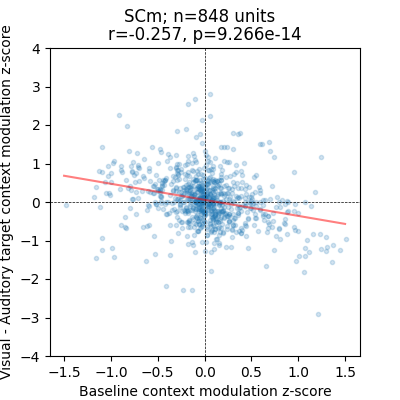

In [19]:
#plot stimulus modulation zscore versus context modulation zscore

sel_structure='SCm'

structure_units=sel_units.query('structure==@sel_structure')

#get fit lines and slopes 

fig,ax=plt.subplots(1,1,figsize=(4,4),sharex=True,sharey=True)
ax.plot(structure_units['baseline_context_modulation_zscore'], structure_units['vis1_evoked_context_modulation_zscore']-structure_units['sound1_evoked_context_modulation_zscore'], '.', alpha=0.2, )
ax.set_xlabel('Baseline context modulation z-score')
ax.set_ylabel('Visual - Auditory target context modulation z-score')
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylim([-4,4])

array1=structure_units['baseline_context_modulation_zscore'].values
array2=(structure_units['vis1_evoked_context_modulation_zscore']-structure_units['sound1_evoked_context_modulation_zscore']).values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
x_array=np.array([-1.5,1.5])
ax.plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax.set_title(f'r={r:.3f}, p={p:.3e}')

fig.suptitle(f'{sel_structure}; n={len(structure_units)} units')

Text(0.5, 0.98, 'SCm; n=848 units')

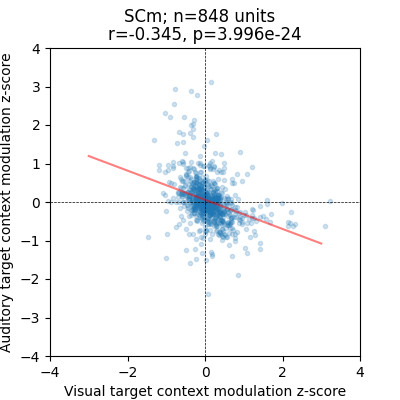

In [20]:
#plot aud vs vis stimulus modulation zscore

sel_structure='SCm'

structure_units=sel_units.query('structure==@sel_structure')

#get fit lines and slopes 

fig,ax=plt.subplots(1,1,figsize=(4,4),sharex=True,sharey=True)
ax.plot(structure_units['vis1_context_modulation_zscore'],structure_units['sound1_context_modulation_zscore'], '.', alpha=0.2, )
ax.set_xlabel('Visual target context modulation z-score')
ax.set_ylabel('Auditory target context modulation z-score')
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylim([-4,4])
ax.set_xlim([-4,4])

array1=structure_units['vis1_context_modulation_zscore'].values
array2=structure_units['sound1_context_modulation_zscore'].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
x_array=np.array([-3,3])
ax.plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax.set_title(f'r={r:.3f}, p={p:.3e}')

fig.suptitle(f'{sel_structure}; n={len(structure_units)} units')

C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_19640\3208181870.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_wise_results=structure_table.groupby(['session_id']).apply(


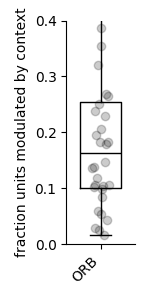

In [21]:
#plot boxplot of chosen variable for list of structures
structure_query='ORBm|ORBvl|ORBl'
# structure_list=['ORBm','ORBvl','ORBl']
structure_list=['ORB']

sel_column='context'

fig,ax=plt.subplots(1,1,figsize=(1.5,3))

for ss,structure_query in enumerate(structure_list):

    structure_table=adj_pvals.query('structure.str.contains(@structure_query) and session_id in @dr_session_list')

    session_wise_results=structure_table.groupby(['session_id']).apply(
        lambda x: (x[sel_column] < 0.05).sum()/x.shape[0]
    ).reset_index().rename(columns={0:'context'})

    #get fraction of units by session

    
    data = session_wise_results['context'].values
    ax.boxplot(data,positions=[ss], widths=0.6, showfliers=False, medianprops=dict(color='black'))

    #jittered scatter plot of individual data points
    ax.scatter(np.random.normal(ss, 0.1, size=data.shape), data, alpha=0.2, color='k')

#remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(len(structure_list)))
ax.set_xticklabels(structure_list,rotation=45,ha='right')
ax.set_yticks(np.arange(0,0.41,0.1))
ax.set_ylabel('fraction units modulated by context')
ax.set_ylim(0,0.4)
fig.tight_layout()

In [22]:
figsavepath=r"C:\Users\ethan.mcbride\OneDrive - Allen Institute\quick figures\2025-10-27-muscimol_sfn_poster"
fig.savefig(os.path.join(figsavepath,'context_modulated_fraction_ORB_combined.png'),dpi=300)

visual target responsive units with visual context preference: 0.54
visual target responsive units with auditory context preference: 0.82
auditory target responsive units with auditory context preference: 0.66
auditory target responsive units with visual context preference: 0.77


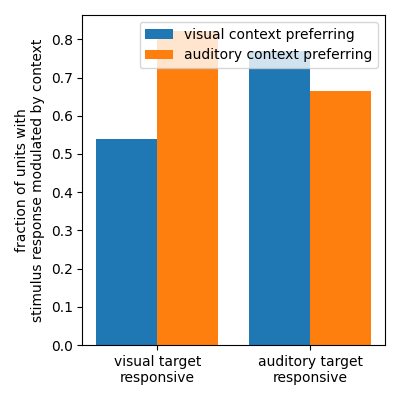

In [23]:
sub_sel_units=sel_units.query('baseline_context_modulation_p_value<0.05')
vis_target_vis_context_pref_units_vis=sub_sel_units.query('vis1_stimulus_modulation_p_value<0.05 and vis1_evoked_context_modulation_p_value<0.05 and baseline_context_modulation_sign==1')
vis_target_aud_context_pref_units_vis=sub_sel_units.query('vis1_stimulus_modulation_p_value<0.05 and vis1_evoked_context_modulation_p_value<0.05 and baseline_context_modulation_sign==-1')
aud_target_aud_context_pref_units_aud=sub_sel_units.query('sound1_stimulus_modulation_p_value<0.05 and sound1_evoked_context_modulation_p_value<0.05 and baseline_context_modulation_sign==-1')
aud_target_vis_context_pref_units_aud=sub_sel_units.query('sound1_stimulus_modulation_p_value<0.05 and sound1_evoked_context_modulation_p_value<0.05 and baseline_context_modulation_sign==1')

vis_target_vis_context_pref=(vis_target_vis_context_pref_units_vis['vis1_evoked_context_modulation_zscore']>=0).mean()
vis_target_aud_context_pref=(vis_target_aud_context_pref_units_vis['vis1_evoked_context_modulation_zscore']>=0).mean()
aud_target_aud_context_pref=(aud_target_aud_context_pref_units_aud['sound1_evoked_context_modulation_zscore']>=0).mean()
aud_target_vis_context_pref=(aud_target_vis_context_pref_units_aud['sound1_evoked_context_modulation_zscore']>=0).mean()

print(f'visual target responsive units with visual context preference: {vis_target_vis_context_pref:.2f}')
print(f'visual target responsive units with auditory context preference: {vis_target_aud_context_pref:.2f}')
print(f'auditory target responsive units with auditory context preference: {aud_target_aud_context_pref:.2f}')
print(f'auditory target responsive units with visual context preference: {aud_target_vis_context_pref:.2f}')

fig,ax=plt.subplots(1,1,figsize=(4,4))
# plot_vect=[[vis_target_vis_context_pref, vis_target_aud_context_pref],
#            [aud_target_vis_context_pref, aud_target_aud_context_pref]]
ax.bar([0,1], [vis_target_vis_context_pref, aud_target_vis_context_pref], width=0.4, label='visual context preferring')
ax.bar([0.4,1.4], [vis_target_aud_context_pref, aud_target_aud_context_pref], width=0.4, label='auditory context preferring')
ax.set_xticks([0.2,1.2])
ax.set_xticklabels(['visual target\nresponsive','auditory target\nresponsive'])
ax.legend(loc='upper right')
ax.set_ylabel('fraction of units with\nstimulus response modulated by context')

fig.tight_layout()

visual target responsive units with visual context preference: 0.22
visual target responsive units with auditory context preference: 0.47
auditory target responsive units with auditory context preference: 0.59
auditory target responsive units with visual context preference: 0.39


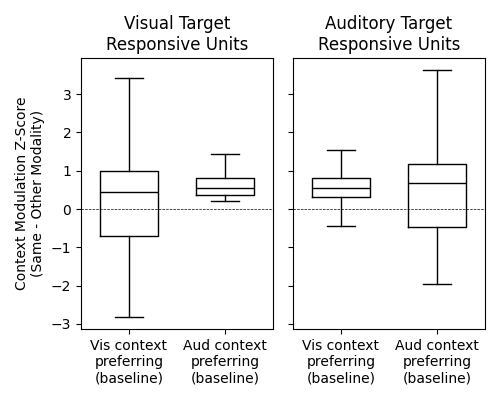

In [24]:
sub_sel_units=sel_units.query('baseline_context_modulation_p_value<0.05')
vis_target_vis_context_pref_units_vis=sub_sel_units.query('vis1_stimulus_modulation_p_value<0.05 and vis1_evoked_context_modulation_p_value<0.05 and baseline_context_modulation_sign==1')
vis_target_aud_context_pref_units_vis=sub_sel_units.query('vis1_stimulus_modulation_p_value<0.05 and vis1_evoked_context_modulation_p_value<0.05 and baseline_context_modulation_sign==-1')
aud_target_aud_context_pref_units_aud=sub_sel_units.query('sound1_stimulus_modulation_p_value<0.05 and sound1_evoked_context_modulation_p_value<0.05 and baseline_context_modulation_sign==-1')
aud_target_vis_context_pref_units_aud=sub_sel_units.query('sound1_stimulus_modulation_p_value<0.05 and sound1_evoked_context_modulation_p_value<0.05 and baseline_context_modulation_sign==1')

vis_target_vis_context_pref=vis_target_vis_context_pref_units_vis['vis1_evoked_context_modulation_zscore'].values
vis_target_vis_context_pref_mean=np.nanmean(vis_target_vis_context_pref[~np.isinf(vis_target_vis_context_pref)])
vis_target_aud_context_pref=vis_target_aud_context_pref_units_vis['vis1_evoked_context_modulation_zscore'].values
vis_target_aud_context_pref_mean=np.nanmean(vis_target_aud_context_pref[~np.isinf(vis_target_aud_context_pref)])

aud_target_aud_context_pref=aud_target_aud_context_pref_units_aud['sound1_evoked_context_modulation_zscore'].values
aud_target_aud_context_pref_mean=np.nanmean(aud_target_aud_context_pref[~np.isinf(aud_target_aud_context_pref)])
aud_target_vis_context_pref=aud_target_vis_context_pref_units_aud['sound1_evoked_context_modulation_zscore'].values
aud_target_vis_context_pref_mean=np.nanmean(aud_target_vis_context_pref[~np.isinf(aud_target_vis_context_pref)])

print(f'visual target responsive units with visual context preference: {vis_target_vis_context_pref_mean:.2f}')
print(f'visual target responsive units with auditory context preference: {vis_target_aud_context_pref_mean:.2f}')
print(f'auditory target responsive units with auditory context preference: {aud_target_aud_context_pref_mean:.2f}')
print(f'auditory target responsive units with visual context preference: {aud_target_vis_context_pref_mean:.2f}')

#boxplot
fig,ax=plt.subplots(1,2,figsize=(5,4),sharey=True)
ax[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
data=[vis_target_vis_context_pref, vis_target_aud_context_pref]
ax[0].boxplot(data, positions=[0,1], widths=0.6, showfliers=False, medianprops=dict(color='black'))
ax[0].set_xticks([0,1])
ax[0].set_xticklabels(['Vis context\npreferring\n(baseline)', 'Aud context\npreferring\n(baseline)'])
ax[0].set_ylabel('Context Modulation Z-Score\n(Same - Other Modality)')
ax[0].set_title('Visual Target\nResponsive Units')

ax[1].axhline(0, color='k', linestyle='--', linewidth=0.5)
data=[aud_target_vis_context_pref, aud_target_aud_context_pref]
ax[1].boxplot(data, positions=[0,1], widths=0.6, showfliers=False, medianprops=dict(color='black'))
ax[1].set_xticks([0,1])
ax[1].set_xticklabels(['Vis context\npreferring\n(baseline)', 'Aud context\npreferring\n(baseline)'])
ax[1].set_title('Auditory Target\nResponsive Units')

fig.tight_layout()

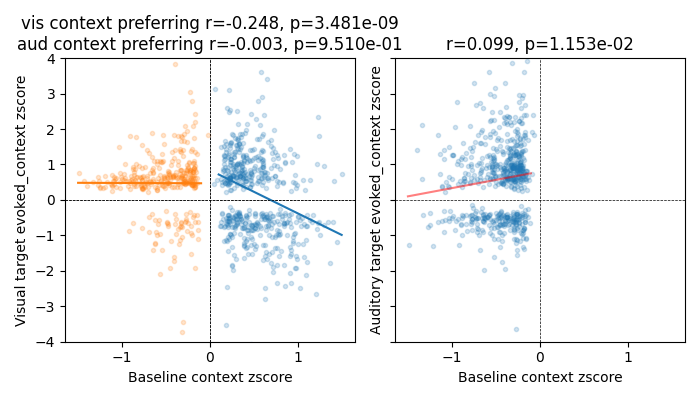

In [25]:
#plot stimulus modulation zscore versus context modulation zscore

sub_sel_units=sel_units.query('baseline_context_modulation_p_value<0.05')
sel_structure='all'
plot_evoked=True
plot_raw_fr=False

if plot_evoked:
    evoked_str='evoked_'
else:
    evoked_str=''

if plot_raw_fr:
    metric_str='raw'
else:
    metric_str='zscore'

if sel_structure=='all':
    structure_units=sub_sel_units
else:
    structure_units=sub_sel_units.query('structure==@sel_structure')

#filter for stim responsive
# structure_units_vis=structure_units.query('vis1_stimulus_modulation_p_value<0.05')
# structure_units_aud=structure_units.query('sound1_stimulus_modulation_p_value<0.05')

structure_units_vis_stim_vis_context=structure_units.query(
    'vis1_stimulus_modulation_p_value<0.05 and vis1_evoked_context_modulation_p_value<0.05 and baseline_context_modulation_sign==1')
structure_units_vis_stim_aud_context=structure_units.query(
    'vis1_stimulus_modulation_p_value<0.05 and vis1_evoked_context_modulation_p_value<0.05 and baseline_context_modulation_sign==-1')
structure_units_aud_stim_aud_context=structure_units.query(
    'sound1_stimulus_modulation_p_value<0.05 and sound1_evoked_context_modulation_p_value<0.05 and baseline_context_modulation_sign==-1')
structure_units_aud_stim_vis_context=structure_units.query(
    'sound1_stimulus_modulation_p_value<0.05 and sound1_evoked_context_modulation_p_value<0.05 and baseline_context_modulation_sign==1')

#get fit lines and slopes 

fig,ax=plt.subplots(1,2,figsize=(7,4),sharex=True,sharey=True)
ax[0].plot(structure_units_vis_stim_vis_context['baseline_context_modulation_'+metric_str], structure_units_vis_stim_vis_context['vis1_'+evoked_str+'context_modulation_'+metric_str], '.', alpha=0.2, )
ax[0].set_xlabel('Baseline context '+metric_str)
ax[0].set_ylabel('Visual target '+evoked_str+'context '+metric_str)
ax[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
ax[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
if plot_raw_fr:
    ax[0].set_ylim([-30,30])
    ax[0].set_xlim([-20,20])
    x_array=np.array([1,15])
else:
    ax[0].set_ylim([-4,4])
    x_array=np.array([0.1,1.5])
array1=structure_units_vis_stim_vis_context['baseline_context_modulation_'+metric_str].values
array2=structure_units_vis_stim_vis_context['vis1_'+evoked_str+'context_modulation_'+metric_str].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
ax[0].plot(x_array, slope*x_array + intercept, color='tab:blue')
r0,p0=stats.pearsonr(array1[valid_indices],array2[valid_indices],)

ax[0].plot(structure_units_vis_stim_aud_context['baseline_context_modulation_'+metric_str], structure_units_vis_stim_aud_context['vis1_'+evoked_str+'context_modulation_'+metric_str], '.', alpha=0.2, )
ax[0].set_xlabel('Baseline context '+metric_str)
ax[0].set_ylabel('Visual target '+evoked_str+'context '+metric_str)
ax[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
ax[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
if plot_raw_fr:
    ax[0].set_ylim([-30,30])
    ax[0].set_xlim([-20,20])
    x_array=np.array([-15,-1])
else:
    ax[0].set_ylim([-4,4])
    x_array=np.array([-1.5,-0.1])
array1=structure_units_vis_stim_aud_context['baseline_context_modulation_'+metric_str].values
array2=structure_units_vis_stim_aud_context['vis1_'+evoked_str+'context_modulation_'+metric_str].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
ax[0].plot(x_array, slope*x_array + intercept, color='tab:orange')
r1,p1=stats.pearsonr(array1[valid_indices],array2[valid_indices],)

ax[0].set_title(f'vis context preferring r={r0:.3f}, p={p0:.3e}\naud context preferring r={r1:.3f}, p={p1:.3e}')
# ax[0].set_title(f'r={r:.3f}, p={p:.3e}')
# ax[0].set_title(f'visual target responsive units')



ax[1].plot(structure_units_aud_stim_aud_context['baseline_context_modulation_'+metric_str], structure_units_aud_stim_aud_context['sound1_'+evoked_str+'context_modulation_'+metric_str], '.', alpha=0.2, )
ax[1].set_xlabel('Baseline context '+metric_str)
ax[1].set_ylabel('Auditory target '+evoked_str+'context '+metric_str)
ax[1].axhline(0, color='k', linestyle='--', linewidth=0.5)
ax[1].axvline(0, color='k', linestyle='--', linewidth=0.5)
if plot_raw_fr:
    ax[1].set_ylim([-30,30])
    ax[1].set_xlim([-20,20])
    x_array=np.array([-15,-1])
else:
    ax[1].set_ylim([-4,4])
    x_array=np.array([-1.5,-0.1])

array1=structure_units_aud_stim_aud_context['baseline_context_modulation_'+metric_str].values
array2=structure_units_aud_stim_aud_context['sound1_'+evoked_str+'context_modulation_'+metric_str].values
valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)

ax[1].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
ax[1].set_title(f'r={r:.3f}, p={p:.3e}')
# ax[1].set_title(f'auditory target responsive units\n(n={len(structure_units_aud)}) r={r:.3f}, p={p:.3e}')

# ax[2].plot(structure_units['baseline_context_modulation_zscore'], structure_units['vis1_context_modulation_zscore']-structure_units['sound1_context_modulation_zscore'], '.', alpha=0.2, )
# ax[2].set_xlabel('Baseline context '+metric_str)
# ax[2].set_ylabel('Visual - Auditory target context '+metric_str)
# ax[2].axhline(0, color='k', linestyle='--', linewidth=0.5)
# ax[2].axvline(0, color='k', linestyle='--', linewidth=0.5)
# ax[2].set_ylim([-4,4])

# array1=structure_units['baseline_context_modulation_zscore'].values
# array2=(structure_units['vis1_context_modulation_zscore']-structure_units['sound1_context_modulation_zscore']).values
# valid_indices = np.isfinite(array1) & np.isfinite(array2) & ~np.isnan(array1) & ~np.isnan(array2)
# slope, intercept, r_value, p_value, std_err = stats.linregress(array1[valid_indices],array2[valid_indices],)
# x_array=np.array([-1.5,1.5])
# ax[2].plot(x_array, slope*x_array + intercept, color='r', alpha=0.5)
# r,p=stats.pearsonr(array1[valid_indices],array2[valid_indices],)
# ax[2].set_title(f'r={r:.3f}, p={p:.3e}')


fig.tight_layout()
